<a href="https://colab.research.google.com/github/supriyamishra0702-supmi/YouTube-Monetization-Modeler/blob/main/Youtube_Content_Monetization_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- STEP 1: LOAD LIBRARIES ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder



In [ ]:
# --- STEP 2: LOAD DATA ---
# Upload 'youtube_ad_revenue_dataset.csv' to Colab files first
df = pd.read_csv('/content/youtube_ad_revenue_dataset.csv')
print("✅ Data loaded successfully!")
print(f"Dataset Shape: {df.shape}")
df.head()


✅ Data loaded successfully!
Dataset Shape: (122400, 12)


,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [ ]:
# --- STEP 3: CLEANING ---
# 1. Remove duplicate rows
df = df.drop_duplicates()




In [ ]:
# 2. Handle Missing Values
# We use the median because it is safer against outliers
df['views'] = df['views'].fillna(df['views'].median())
df['likes'] = df['likes'].fillna(df['likes'].median())
df['comments'] = df['comments'].fillna(df['comments'].median())



In [ ]:
# --- STEP 4: FEATURE ENGINEERING ---
# We create the 'Engagement Rate'
# Formula: (Likes + Comments) / Views
df['engagement_rate'] = (df['likes'] + df['comments']) / (df['views'] + 1)



In [ ]:
# --- STEP 5: ENCODING ---
# Convert text categories into numbers so the model can read them
encoders = {}
for col in ['category', 'device', 'country']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# Save the encoders for use in our Streamlit app later
joblib.dump(encoders, 'label_encoders.pkl')
print("✅ Cleaning and Encoding complete!")

✅ Cleaning and Encoding complete!


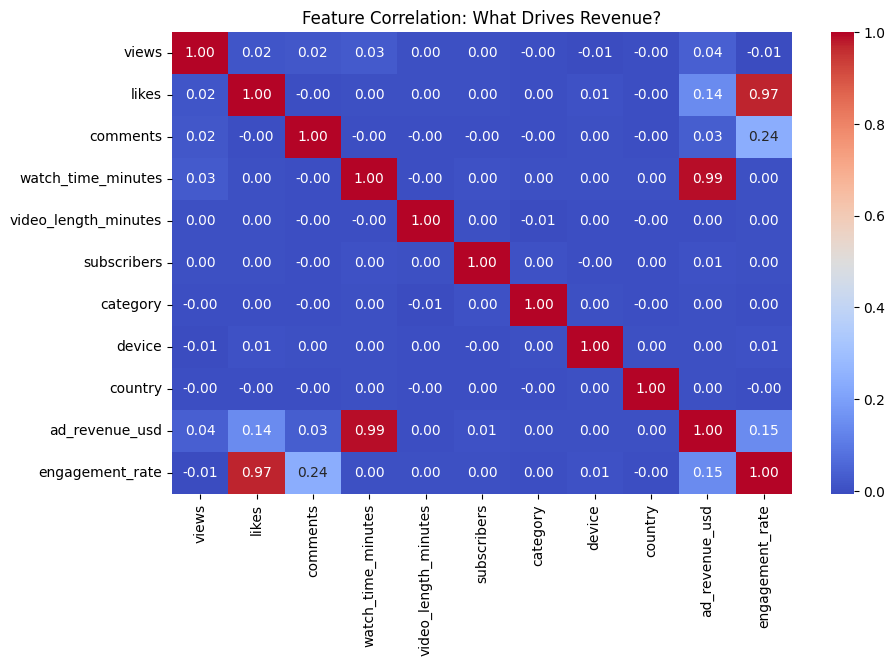

In [ ]:
# --- STEP 6: VISUALIZATION ---

# 1. Create the Correlation Heatmap
plt.figure(figsize=(10, 6))


correlation_matrix = df.corr(numeric_only=True)

# Generate the heatmap using the numeric-only matrix
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Feature Correlation: What Drives Revenue?")
plt.savefig('correlation_heatmap.png')
plt.show()




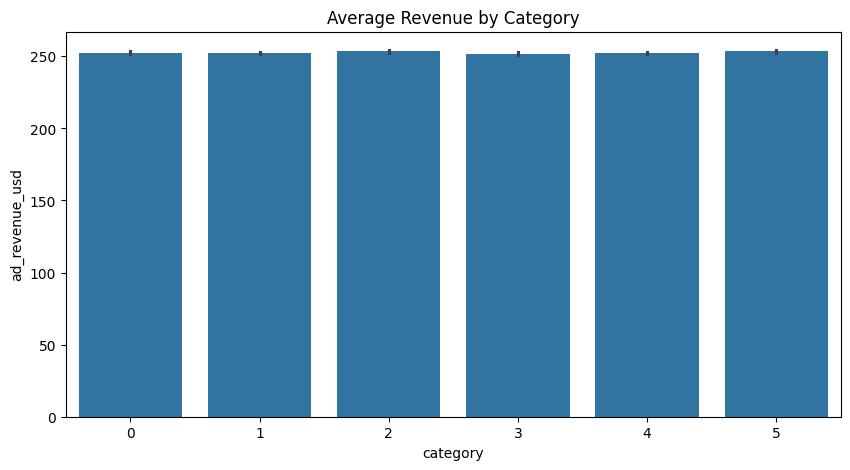

✅ EDA Visuals generated successfully!


In [ ]:
# 2. Create Revenue by Category chart
plt.figure(figsize=(10, 5))

# We use the categorical data
sns.barplot(x='category', y='ad_revenue_usd', data=df)

plt.title("Average Revenue by Category")
plt.savefig('category_insights.png')
plt.show()

print("✅ EDA Visuals generated successfully!")

In [ ]:
# Define the columns :
feature_cols = [
    'views', 'likes', 'comments', 'watch_time_minutes',
    'video_length_minutes', 'subscribers', 'category',
    'device', 'country', 'engagement_rate'
]


print("Empty values before final fix:")
print(df[feature_cols].isnull().sum())



Empty values before final fix:
views                      0
likes                      0
comments                   0
watch_time_minutes      6000
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
engagement_rate            0
dtype: int64


In [ ]:
# 2. Drop any remaining rows with NaN values

df = df.dropna(subset=feature_cols)



In [ ]:
# 3. Double-check again
print("\nEmpty values after final fix:")
print(df[feature_cols].isnull().sum())




Empty values after final fix:
views                   0
likes                   0
comments                0
watch_time_minutes      0
video_length_minutes    0
subscribers             0
category                0
device                  0
country                 0
engagement_rate         0
dtype: int64


In [ ]:
# Now re-assign X and y with the cleaned data
X = df[feature_cols]
y = df['ad_revenue_usd']

# Re-run the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n✅ Data is now 100% clean. You can run the model fit now!")



✅ Data is now 100% clean. You can run the model fit now!


In [ ]:
# --- STEP 7: SELECTING FEATURES & TARGET ---

# We choose the columns that help predict revenue.

feature_cols = [
    'views', 'likes', 'comments', 'watch_time_minutes',
    'video_length_minutes', 'subscribers', 'category',
    'device', 'country', 'engagement_rate'
]

X = df[feature_cols]
y = df['ad_revenue_usd']



In [ ]:
# --- STEP 8: SPLITTING THE DATA ---


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




In [ ]:
# --- STEP 9: THE 5-MODEL SHOOTOUT (With RMSE) ---
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# 1. Define the 5 models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# 2. Print Header
print(f"{'Model Name':<20} | {'R²':<7} | {'MAE':<8} | {'RMSE':<8}")
print("-" * 55)

# 3. Loop and Evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    print(f"{name:<20} | {r2:<7.4f} | ${mae:<7.2f} | ${rmse:<7.2f}")

# 4. Save the Winner
joblib.dump(models["Random Forest"], 'final_model.pkl')
print("-" * 55)
print("✅ Results complete. Random Forest is the best-performing model.")



Model Name           | R²      | MAE      | RMSE    
-------------------------------------------------------
Linear Regression    | 0.9989  | $0.49    | $2.04   
Ridge Regression     | 0.9989  | $0.49    | $2.04   
Lasso Regression     | 0.9989  | $0.49    | $2.04   
Decision Tree        | 0.9983  | $1.60    | $2.57   
Random Forest        | 0.9987  | $0.88    | $2.20   
-------------------------------------------------------
✅ Results complete. Random Forest is the best-performing model.


In [ ]:
from google.colab import files

# List of files to download for GitHub/App
files_to_download = [
    'final_model.pkl',
    'label_encoders.pkl',
    'correlation_heatmap.png',
    'category_insights.png'
]

for file in files_to_download:
    try:
        files.download(file)
    except:
        print(f"Error: {file} not found. Make sure you ran the previous cells!")




<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>